In [1]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_dir = os.path.join(os.getcwd(), 'data', 'raw_pupil')
subj_dirs = sorted([d for d in glob.glob(os.path.join(data_dir, '*')) if d.split('/')[-1] != 'sub-000'])

all_dms = {}

for subj_dir in subj_dirs:
    subj = subj_dir.split('/')[-1]
    print(f'Processing {subj}...')

    subj_dms = []
    events_files = sorted(glob.glob(os.path.join(subj_dir, '*_events.tsv')))
    events_files = events_files[1:] # skip run-0

    params_files = sorted(glob.glob(os.path.join(subj_dir, '*_params.csv')))
    params_files = params_files[1:]

    for i, events_file in enumerate(events_files):
        events_df = pd.read_csv(events_file, sep='\t')
        params_df = pd.read_csv(params_files[i])

        run_id = events_file.split('/')[-1].split('_')[2]
        run_time = int(events_df['onset'].iloc[-1] + events_df['duration'].iloc[events_df['duration'].last_valid_index()])
        tr = 2 
        n_volumes = run_time // tr
        conditions = sorted(events_df['condition'].unique()) # ['blank', 'empty', 'left', 'right']
        dm = np.zeros((n_volumes, len(conditions) - 1)) # we do not code blank trials

        for i, cond in enumerate(params_df['condition']):
            if (cond == conditions[1]):  # empty
                dm[i * tr, 0] = 1
            elif cond == conditions[2]:  # left
                dm[i * tr, 1] = 1
            elif cond == conditions[3]:  # right
                dm[i * tr, 2] = 1
        
        subj_dms.append(dm)

    all_dms[subj] = subj_dms

Processing sub-001...
Processing sub-002...
Processing sub-003...
Processing sub-004...
Processing sub-005...
Processing sub-006...
Processing sub-007...
Processing sub-008...
Processing sub-009...
Processing sub-010...
Processing sub-011...
Processing sub-012...
Processing sub-013...
Processing sub-014...
Processing sub-015...
Processing sub-016...
Processing sub-017...
Processing sub-018...


In [2]:
all_dms['sub-001'][0].shape

(401, 3)

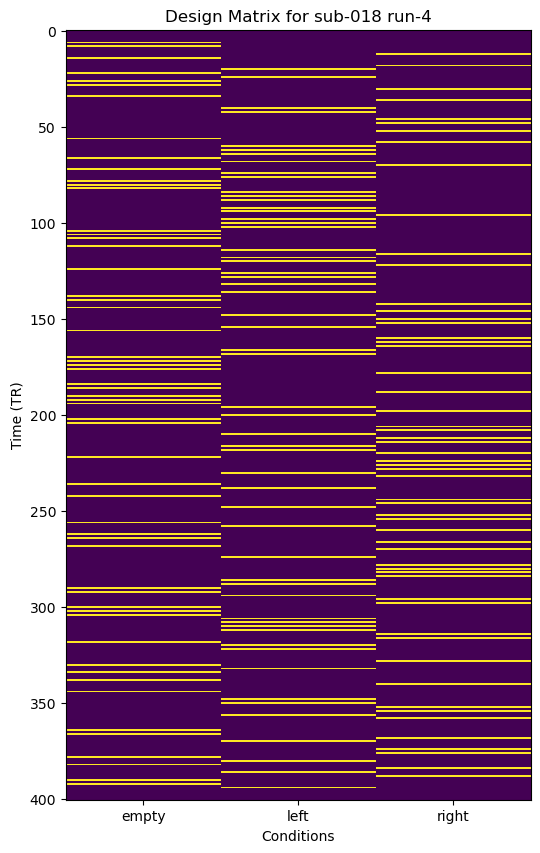

In [3]:
plt.figure(figsize=(6,10))
plt.imshow(all_dms['sub-001'][0], aspect='auto', interpolation='none')
plt.title(f'Design Matrix for {subj} {run_id}')
plt.xlabel('Conditions')
plt.ylabel('Time (TR)')
plt.xticks(ticks=np.arange(len(conditions) - 1), labels=conditions[1:])
plt.show()